<a href="https://colab.research.google.com/github/MoSahil147/DeepFake-Detection-in-Online-Social-Network-OSN-Using-Advanced-Machine-Learning/blob/main/Design_Project_DeepFake_Detection_in_Online_Social_Network_(OSN)_Using_Advanced_Machine_Learning_Sahil_Mohapatra_(2022A7PS0112U).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/DeepFake Datasets/FakeAVCeleb_v1.2.zip"
extract_path = "/content/FakeAVCeleb_v1.2"

print("🔄 Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Extraction complete! Files extracted to: {extract_path}")

🔄 Unzipping dataset...
✅ Extraction complete! Files extracted to: /content/FakeAVCeleb_v1.2


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(f"📂 Folder: {root}")
    print(f"📁 Subfolders: {dirs}")
    print(f"📄 Files (sample): {files[:5]}")
    break  # Only top level

📂 Folder: /content/FakeAVCeleb_v1.2
📁 Subfolders: ['FakeAVCeleb_v1.2']
📄 Files (sample): []


In [ ]:
!pip install opencv-python moviepy torch torchvision librosa

In [ ]:
import subprocess

video_dir = "/content/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"
audio_output_dir = "/content/audio_clips"
os.makedirs(audio_output_dir, exist_ok=True)

def collect_video_paths(base_path):
    paths = []
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.endswith(".mp4"):
                paths.append(os.path.join(root, file))
    return paths

# Collect paths
real_videos = collect_video_paths(os.path.join(video_dir, "RealVideo-RealAudio"))
fake_videos = collect_video_paths(os.path.join(video_dir, "FakeVideo-RealAudio"))

# Extraction function
def extract_audio_batch(videos, category):
    count, errors = 0, []
    for i, video_path in enumerate(videos):
        rel = os.path.relpath(video_path, video_dir)
        audio_path = os.path.join(audio_output_dir, rel.replace(".mp4", ".wav"))
        os.makedirs(os.path.dirname(audio_path), exist_ok=True)

        print(f"🔊 [{category}] ({i+1}/{len(videos)}): {os.path.basename(video_path)}")
        cmd = ["ffmpeg", "-i", video_path, "-q:a", "0", "-map", "a", audio_path, "-y"]
        try:
            subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            count += 1
        except subprocess.CalledProcessError:
            print(f"❌ Failed: {video_path}")
            errors.append(video_path)
    return count, errors

# Extract
real_count, real_err = extract_audio_batch(real_videos, "Real")
fake_count, fake_err = extract_audio_batch(fake_videos, "Fake")

print(f"\n✅ Audio Extraction Done!")
print(f"🎯 Real: {real_count} | 🎯 Fake: {fake_count}")
print(f"⚠️ Errors: {len(real_err) + len(fake_err)}")

Streaming output truncated to the last 5000 lines.
🔊 [Fake] (4714/9709): 00040_id00068_wavtolip.mp4
🔊 [Fake] (4715/9709): 00040_id00330_wavtolip.mp4
🔊 [Fake] (4716/9709): 00040_id00373_wavtolip.mp4
🔊 [Fake] (4717/9709): 00040_id00365_wavtolip.mp4
🔊 [Fake] (4718/9709): 00040_id00234_wavtolip.mp4
🔊 [Fake] (4719/9709): 00040_id00379_fgkgYHCuk4g.mp4
🔊 [Fake] (4720/9709): 00040_id00633_wavtolip.mp4
🔊 [Fake] (4721/9709): 00040_id00813_wavtolip.mp4
🔊 [Fake] (4722/9709): 00040_id00591_1Jo8xElXQMs.mp4
🔊 [Fake] (4723/9709): 00040_id00897_0ayFw8JhoyI.mp4
🔊 [Fake] (4724/9709): 00040_id03816_XXD0yTNei50.mp4
🔊 [Fake] (4725/9709): 00040_id03651_EjcoRkL6loI_faceswap.mp4
🔊 [Fake] (4726/9709): 00040_id00328_wavtolip.mp4
🔊 [Fake] (4727/9709): 00040_id00332__zNddcZV1EU.mp4
🔊 [Fake] (4728/9709): 00040_0.mp4
🔊 [Fake] (4729/9709): 00040_id03716_wavtolip.mp4
🔊 [Fake] (4730/9709): 00040_id00365_XV-imLNJvfk.mp4
🔊 [Fake] (4731/9709): 00040_id00826_wavtolip.mp4
🔊 [Fake] (4732/9709): 00040_id03651_EjcoRkL6loI.mp4


In [ ]:
frame_output_dir = "/content/video_frames"
os.makedirs(frame_output_dir, exist_ok=True)

all_videos = real_videos + fake_videos
errors = []

for idx, video_path in enumerate(all_videos):
    rel_path = os.path.relpath(video_path, video_dir)
    frame_folder = os.path.join(frame_output_dir, rel_path.replace(".mp4", ""))
    os.makedirs(frame_folder, exist_ok=True)

    print(f"\n🖼️ [{idx+1}/{len(all_videos)}] Extracting frames from: {os.path.basename(video_path)}")
    cmd = [
        "ffmpeg", "-i", video_path, "-vf", "fps=1",
        os.path.join(frame_folder, "frame_%04d.jpg")
    ]
    try:
        subprocess.run(cmd, check=True)
        print(f"✅ Frames saved in: {frame_folder}")
    except subprocess.CalledProcessError:
        print(f"❌ Frame extraction failed for: {video_path}")
        errors.append(video_path)

print(f"\n✅ Frame extraction complete. Total failures: {len(errors)}")

Streaming output truncated to the last 5000 lines.

🖼️ [8544/10209] Extracting frames from: 00092_id00087_wavtolip.mp4
✅ Frames saved in: /content/video_frames/FakeVideo-RealAudio/Caucasian (American)/men/id00775/00092_id00087_wavtolip

🖼️ [8545/10209] Extracting frames from: 00092_id03757_L-M-XbdFLQM.mp4
✅ Frames saved in: /content/video_frames/FakeVideo-RealAudio/Caucasian (American)/men/id00775/00092_id03757_L-M-XbdFLQM

🖼️ [8546/10209] Extracting frames from: 00092_id01239_wavtolip.mp4
✅ Frames saved in: /content/video_frames/FakeVideo-RealAudio/Caucasian (American)/men/id00775/00092_id01239_wavtolip

🖼️ [8547/10209] Extracting frames from: 00092_id00049_S_EHTUF-mQY.mp4
✅ Frames saved in: /content/video_frames/FakeVideo-RealAudio/Caucasian (American)/men/id00775/00092_id00049_S_EHTUF-mQY

🖼️ [8548/10209] Extracting frames from: 00092_id00943_LxSv2rnBGA8.mp4
✅ Frames saved in: /content/video_frames/FakeVideo-RealAudio/Caucasian (American)/men/id00775/00092_id00943_LxSv2rnBGA8

🖼️ [8

In [ ]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import librosa

# Load MobileNetV2
print("🔄 Loading MobileNetV2...")
model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("✅ Model loaded.")

def extract_visual_features(frame_folder):
    print("🖼️ Extracting visual features...")
    frames = sorted([f for f in os.listdir(frame_folder) if f.endswith(".jpg")])
    if not frames:
        raise ValueError("No frames found in folder.")

    features = []
    for frame in frames[:5]:  # first 5
        img_path = os.path.join(frame_folder, frame)
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(np.expand_dims(x, axis=0))
        feat = model.predict(x, verbose=0)
        features.append(feat[0])
    return np.mean(features, axis=0)

def extract_audio_features(audio_path):
    print("🎧 Extracting audio features...")
    y, sr = librosa.load(audio_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    return np.mean(mfcc.T, axis=0)

🔄 Loading MobileNetV2...


<ipython-input-11-2c104be80c0c>:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model loaded.


In [ ]:
X, y = [], []
skipped, total = 0, 0

print("🚀 Starting dataset generation...\n")

for root, _, files in os.walk(audio_output_dir):
    for file in files:
        if file.endswith(".wav"):
            total += 1
            audio_path = os.path.join(root, file)

            # ✅ Correct relative path construction
            rel_path = os.path.relpath(audio_path, audio_output_dir)
            frame_folder = os.path.join(frame_output_dir, rel_path.replace(".wav", ""))

            print(f"\n🔍 Processing: {rel_path}")
            if not os.path.exists(audio_path) or not os.path.exists(frame_folder):
                print("⚠️ Missing frame or audio folder. Skipping.")
                skipped += 1
                continue

            try:
                visual_feat = extract_visual_features(frame_folder)
                audio_feat = extract_audio_features(audio_path)
                combined = np.concatenate([visual_feat, audio_feat])
                X.append(combined)

                label = 1 if "FakeVideo" in audio_path else 0
                y.append(label)
                print(f"✅ Done: {'Fake' if label else 'Real'}")
            except Exception as e:
                print(f"❌ Error: {e}")
                skipped += 1

# Save final arrays
X = np.array(X)
y = np.array(y)

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print("\n🎉 Feature extraction complete!")
print(f"📦 Total videos processed: {len(X)}")
print(f"⚠️ Total skipped: {skipped}")
print(f"🔢 Feature shape: {X.shape} | Labels shape: {y.shape}")

Streaming output truncated to the last 5000 lines.

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_id00261_gYQ5Scz5FnA.wav
🖼️ Extracting visual features...
🎧 Extracting audio features...
✅ Done: Fake

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_id00145_JveyoCdoCuI.wav
🖼️ Extracting visual features...
🎧 Extracting audio features...
✅ Done: Fake

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_id00097_wavtolip.wav
🖼️ Extracting visual features...
🎧 Extracting audio features...
✅ Done: Fake

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_3.wav
🖼️ Extracting visual features...
🎧 Extracting audio features...
✅ Done: Fake

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_id03556_wavtolip.wav
🖼️ Extracting visual features...
🎧 Extracting audio features...
✅ Done: Fake

🔍 Processing: FakeVideo-RealAudio/Caucasian (American)/women/id03605/00048_id01231_wavt

📂 Loading dataset...
✅ Loaded X: (10209, 1300), y: (10209,)

🔀 Splitting (80% train, 20% test)...
🧪 Train: 8167 | 🧾 Test: 2042

⚖️ Computing class weights for imbalance handling...
✅ Class Weights: {0: np.float64(10.497429305912597), 1: np.float64(0.5250064283877603)}

🛠️ Building MLP model...
✅ Model compiled.

🚀 Training with class weights...



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5588 - loss: 3.0867 - val_accuracy: 0.9388 - val_loss: 0.2439
Epoch 2/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6142 - loss: 0.6952 - val_accuracy: 0.8546 - val_loss: 0.4917
Epoch 3/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5753 - loss: 0.6697 - val_accuracy: 0.5979 - val_loss: 0.5864
Epoch 4/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5982 - loss: 0.6069 - val_accuracy: 0.6420 - val_loss: 0.5819
Epoch 5/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6536 - loss: 0.5856 - val_accuracy: 0.5304 - val_loss: 0.6078
Epoch 6/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6664 - loss: 0.5473 - val_accuracy: 0.5343 - val_loss: 0.7323
Epoch 7/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6805 - loss: 0.5467 - val_accuracy: 0.6680 - val_loss: 0.5423
Epoch 8/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7437 - loss: 0.5014 - val_accu

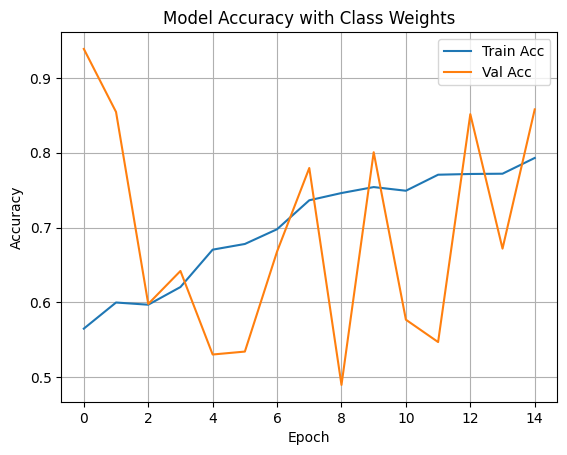


💾 Model saved as 'deepfake_mlp_balanced.h5'


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Step 1: Load dataset
print("📂 Loading dataset...")
X = np.load("X_features.npy")
y = np.load("y_labels.npy")
print(f"✅ Loaded X: {X.shape}, y: {y.shape}")

# Step 2: Split the dataset
print("\n🔀 Splitting (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"🧪 Train: {len(X_train)} | 🧾 Test: {len(X_test)}")

# Step 3: Compute class weights
print("\n⚖️ Computing class weights for imbalance handling...")
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print(f"✅ Class Weights: {class_weights}")

# Step 4: Define the model
print("\n🛠️ Building MLP model...")
model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Model compiled.")

# Step 5: Train the model with class weights
print("\n🚀 Training with class weights...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

# Step 6: Evaluation
print("\n📊 Evaluating model...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

# Step 7: Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix
print("🔍 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 9: Plot accuracy curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy with Class Weights')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Save model
model.save("deepfake_mlp_balanced.h5")
print("\n💾 Model saved as 'deepfake_mlp_balanced.h5'")